In [1]:
# choice of wt seed and library-cluster set (200k libs)
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import h5py
import logomaker

SEQ_ID = "peak84030"        # one of the 8 seeds in seam_seeds.csv
CONFIG = "200k_k100"
CONFIGS = {
    "200k_k100": ("foregrounds_200k", "_200k"),
}
FG_NAME, LIB_SUFFIX = CONFIGS[CONFIG]

R = Path("/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq")
fg_dir = R / FG_NAME / SEQ_ID
with h5py.File(R / f"ism{LIB_SUFFIX}/{SEQ_ID}.h5") as f:
    attributions = f["ism_centered"][:]          # (N, 200, 4)
cluster_labels = np.load(fg_dir / "cluster_labels.npy")
wt_cluster = cluster_labels[0]                    # ref_idx=0 = WT reference


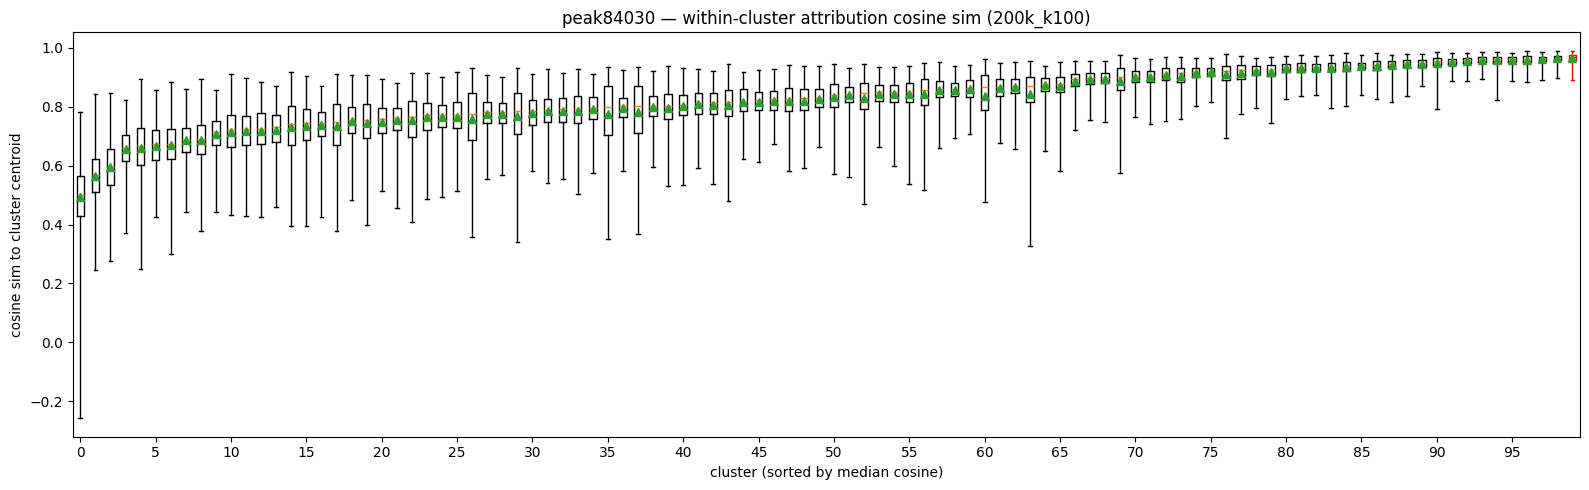

In [2]:
# per-cluster member-to-centroid cosine sim, as box plots (whiskers = full range, ● = mean)
cos_by_cluster = []
for c in range(cluster_labels.max() + 1):
    m = attributions[cluster_labels == c].reshape((cluster_labels == c).sum(), -1)
    ctr = m.mean(0)
    cos_by_cluster.append(m @ ctr / (np.linalg.norm(m, axis=1) * np.linalg.norm(ctr)))

plt.figure(figsize=(16, 5))
order = sorted(range(len(cos_by_cluster)), key=lambda i: np.median(cos_by_cluster[i]))
data = [cos_by_cluster[i] for i in order]
bp = plt.boxplot(data, showmeans=True, showfliers=False, whis=(0, 100))
wt_pos = order.index(wt_cluster)
bp['boxes'][wt_pos].set_color('red'); bp['medians'][wt_pos].set_color('red')
for k in ('whiskers', 'caps'):
    bp[k][2 * wt_pos].set_color('red'); bp[k][2 * wt_pos + 1].set_color('red')
plt.xticks(range(1, len(data) + 1, 5), range(0, len(data), 5))
plt.xlabel("cluster (sorted by median cosine)")
plt.ylabel("cosine sim to cluster centroid")
plt.title(f"{SEQ_ID} — within-cluster attribution cosine sim ({CONFIG})")
plt.tight_layout()


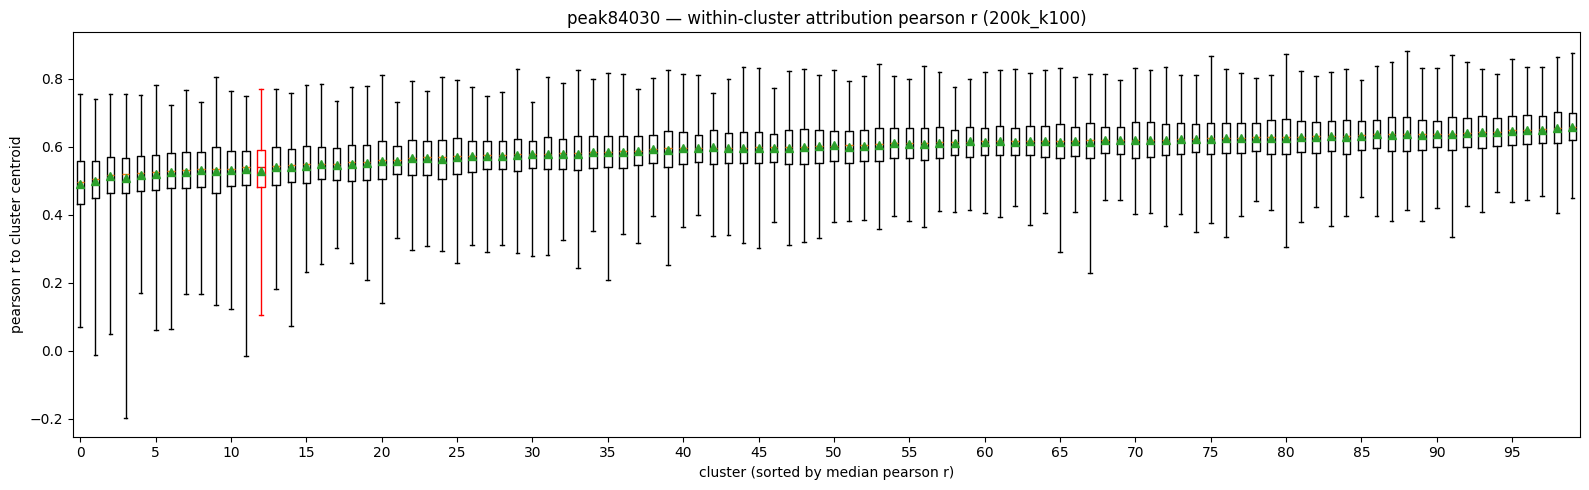

In [3]:
# same box plots, but per-position Pearson r across the 4 channels (member vs centroid), averaged over positions
pear_by_cluster = []
for c in range(cluster_labels.max() + 1):
    M = attributions[cluster_labels == c]              # (n, 200, 4)
    a = M - M.mean(-1, keepdims=True)                  # center each position across channels
    b = M.mean(0); b = b - b.mean(-1, keepdims=True)   # centroid, same centering
    r = (a * b).sum(-1) / np.sqrt((a**2).sum(-1) * (b**2).sum(-1))   # (n, 200) per-position r
    pear_by_cluster.append(np.nanmean(r, axis=1))      # mean over positions -> one r per member

plt.figure(figsize=(16, 5))
order = sorted(range(len(pear_by_cluster)), key=lambda i: np.median(pear_by_cluster[i]))
data = [pear_by_cluster[i] for i in order]
bp = plt.boxplot(data, showmeans=True, showfliers=False, whis=(0, 100))
wt_pos = order.index(wt_cluster)
bp['boxes'][wt_pos].set_color('red'); bp['medians'][wt_pos].set_color('red')
for k in ('whiskers', 'caps'):
    bp[k][2 * wt_pos].set_color('red'); bp[k][2 * wt_pos + 1].set_color('red')
plt.xticks(range(1, len(data) + 1, 5), range(0, len(data), 5))
plt.xlabel("cluster (sorted by median pearson r)")
plt.ylabel("pearson r to cluster centroid")
plt.title(f"{SEQ_ID} — within-cluster attribution pearson r ({CONFIG})")
plt.tight_layout()


In [4]:
# summary stats: within-cluster range (max - min) of each metric
cos_range = np.array([c.max() - c.min() for c in cos_by_cluster])
pear_range = np.array([p.max() - p.min() for p in pear_by_cluster])

print(f"WT cluster {wt_cluster}:  cossim range {cos_range[wt_cluster]:.3f}   pearson range {pear_range[wt_cluster]:.3f}")
print(f"largest cossim range:    cluster {cos_range.argmax()}  ({cos_range.max():.3f})")
print(f"largest pearson range:   cluster {pear_range.argmax()}  ({pear_range.max():.3f})")
print(f"average range:           cossim {cos_range.mean():.3f}   pearson {pear_range.mean():.3f}")


WT cluster 89:  cossim range 0.099   pearson range 0.665
largest cossim range:    cluster 7  (1.042)
largest pearson range:   cluster 7  (0.955)
average range:           cossim 0.338   pearson 0.492


In [5]:
# sweep every library-cluster set for this seed -> one comparison table
rows = []
for cfg, (fg_name, lib_suffix) in CONFIGS.items():
    with h5py.File(R / f"ism{lib_suffix}/{SEQ_ID}.h5") as f:
        attr = f["ism_centered"][:]
    labels = np.load(R / fg_name / SEQ_ID / "cluster_labels.npy")
    wt = labels[0]

    cos_r, pear_r = [], []
    for c in range(labels.max() + 1):
        M = attr[labels == c]
        flat = M.reshape(len(M), -1); ctr = flat.mean(0)
        cos = flat @ ctr / (np.linalg.norm(flat, axis=1) * np.linalg.norm(ctr))
        a = M - M.mean(-1, keepdims=True); b = M.mean(0); b = b - b.mean(-1, keepdims=True)
        r = np.nanmean((a * b).sum(-1) / np.sqrt((a**2).sum(-1) * (b**2).sum(-1)), axis=1)
        cos_r.append(cos.max() - cos.min()); pear_r.append(r.max() - r.min())
    cos_r, pear_r = np.array(cos_r), np.array(pear_r)

    rows.append({
        "config": cfg, "n_clusters": len(cos_r),
        "wt_cossim_range": cos_r[wt], "wt_pearson_range": pear_r[wt],
        "max_cossim_range": cos_r.max(), "max_cossim_cluster": cos_r.argmax(),
        "max_pearson_range": pear_r.max(), "max_pearson_cluster": pear_r.argmax(),
        "avg_cossim_range": cos_r.mean(), "avg_pearson_range": pear_r.mean(),
    })

summary = pd.DataFrame(rows).set_index("config").round(3)
summary


,n_clusters,wt_cossim_range,wt_pearson_range,max_cossim_range,max_cossim_cluster,max_pearson_range,max_pearson_cluster,avg_cossim_range,avg_pearson_range
config,,,,,,,,,
200k_k100,100,0.099,0.665,1.042,7,0.955,7,0.338,0.492


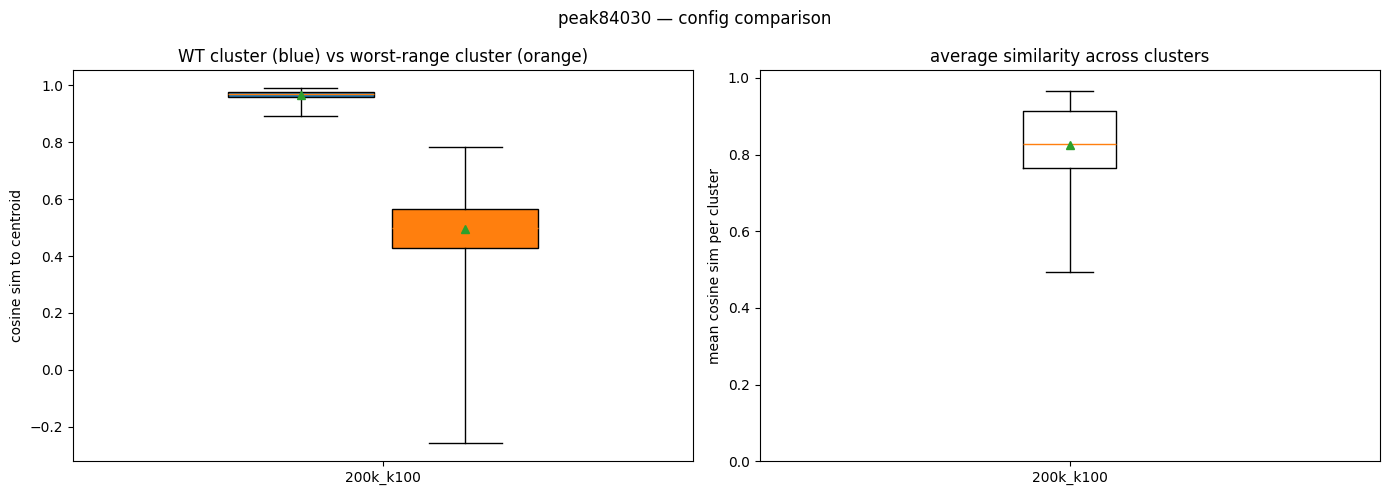

In [6]:
# config comparison (cosine sim): (left) WT vs worst-range cluster; (right) per-cluster mean across all clusters
configs = list(CONFIGS)

wt_boxes, worst_boxes, avg_boxes = [], [], []
for cfg in configs:
    fg_name, lib_suffix = CONFIGS[cfg]
    with h5py.File(R / f"ism{lib_suffix}/{SEQ_ID}.h5") as f:
        attr = f["ism_centered"][:]
    labels = np.load(R / fg_name / SEQ_ID / "cluster_labels.npy")

    cos = []
    for c in range(labels.max() + 1):
        m = attr[labels == c].reshape((labels == c).sum(), -1); ctr = m.mean(0)
        cos.append(m @ ctr / (np.linalg.norm(m, axis=1) * np.linalg.norm(ctr)))
    rng = np.array([c.max() - c.min() for c in cos])
    wt_boxes.append(cos[labels[0]])                       # WT cluster's member distribution
    worst_boxes.append(cos[rng.argmax()])                 # largest-range (least self-consistent) cluster
    avg_boxes.append(np.array([c.mean() for c in cos]))   # per-cluster mean -> distribution across clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos = np.arange(len(configs))
axes[0].boxplot(wt_boxes, positions=pos - 0.18, widths=0.32, showmeans=True, showfliers=False,
                whis=(0, 100), patch_artist=True, boxprops=dict(facecolor="C0"))
axes[0].boxplot(worst_boxes, positions=pos + 0.18, widths=0.32, showmeans=True, showfliers=False,
                whis=(0, 100), patch_artist=True, boxprops=dict(facecolor="C1"))
axes[0].set_xticks(pos); axes[0].set_xticklabels(configs)
axes[0].set_ylabel("cosine sim to centroid")
axes[0].set_title("WT cluster (blue) vs worst-range cluster (orange)")

axes[1].boxplot(avg_boxes, showmeans=True, showfliers=False, whis=(0, 100))
axes[1].set_xticks(pos + 1); axes[1].set_xticklabels(configs)
axes[1].set_ylabel("mean cosine sim per cluster")
axes[1].set_title("average similarity across clusters")
axes[1].set_ylim(0,1.02)
fig.suptitle(f"{SEQ_ID} — config comparison")
plt.tight_layout()


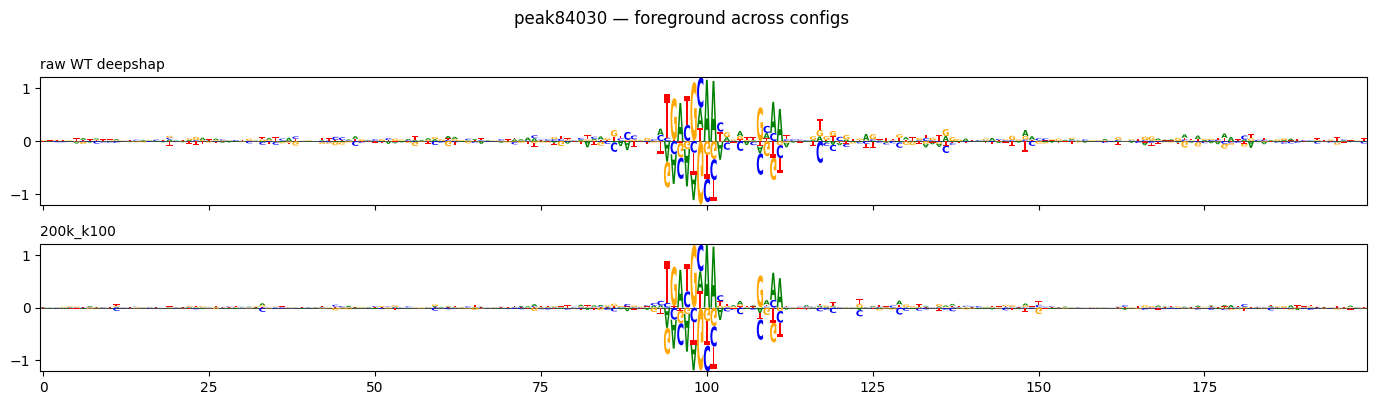

In [7]:
# foregrounds across configs for this seed, raw WT deepshap map on top
logos = {"raw WT deepshap": np.load(fg_dir / "wt_attribution.npy")}   # WT map, config-independent
logos.update({cfg: np.load(R / fg / SEQ_ID / "foreground_scaled.npy") for cfg, (fg, _) in CONFIGS.items()})

fig, axes = plt.subplots(len(logos), 1, figsize=(14, 2 * len(logos)), sharex=True)
for ax, (title, arr) in zip(axes, logos.items()):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    ax.set_title(title, loc="left", fontsize=10)
fig.suptitle(f"{SEQ_ID} — foreground across configs", y=1.001)
plt.tight_layout()


TypeError: 'Axes' object is not iterable

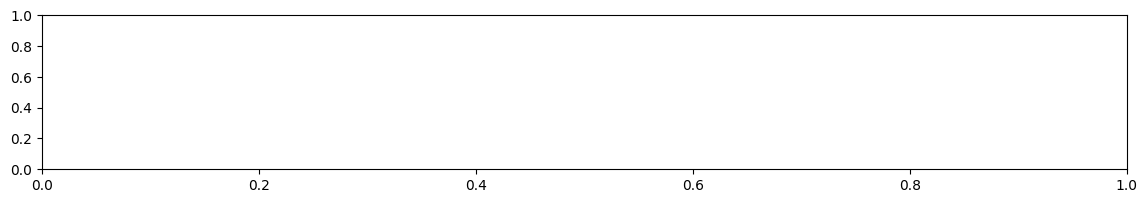

In [8]:
# scaled background across configs for this seed
logos = {cfg: np.load(R / fg / SEQ_ID / "average_background_scaled.npy") for cfg, (fg, _) in CONFIGS.items()}

fig, axes = plt.subplots(len(logos), 1, figsize=(14, 2 * len(logos)), sharex=True)
for ax, (title, arr) in zip(axes, logos.items()):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    ax.set_title(title, loc="left", fontsize=10)
fig.suptitle(f"{SEQ_ID} — scaled background across configs", y=1.001)
plt.tight_layout()


In [ ]:
# intracluster background (WT cluster) across configs for this seed
logos = {}
for cfg, (fg, _) in CONFIGS.items():
    d = R / fg / SEQ_ID
    ref = int(np.load(d / "ref_cluster_idx.npy"))
    logos[cfg] = np.load(d / "cluster_backgrounds.npy")[ref]

fig, axes = plt.subplots(len(logos), 1, figsize=(14, 2 * len(logos)), sharex=True)
for ax, (title, arr) in zip(axes, logos.items()):
    logomaker.Logo(pd.DataFrame(arr, columns=list("ACGT")), ax=ax)
    ax.set_title(title, loc="left", fontsize=10)
fig.suptitle(f"{SEQ_ID} — intracluster background across configs", y=1.001)
plt.tight_layout()


In [ ]:
# spearman rho of each config's background vs the 200k_k100 reference
from scipy.stats import spearmanr
ref_dir = R / CONFIGS["200k_k100"][0] / SEQ_ID
ref_intra = np.load(ref_dir / "cluster_backgrounds.npy")[int(np.load(ref_dir / "ref_cluster_idx.npy"))].ravel()
ref_avg = np.load(ref_dir / "average_background.npy").ravel()

intra_rho, avg_rho = [], []
for cfg, (fg, _) in CONFIGS.items():
    d = R / fg / SEQ_ID
    intra = np.load(d / "cluster_backgrounds.npy")[int(np.load(d / "ref_cluster_idx.npy"))].ravel()
    intra_rho.append(spearmanr(intra, ref_intra)[0])
    avg_rho.append(spearmanr(np.load(d / "average_background.npy").ravel(), ref_avg)[0])

x = range(len(CONFIGS))
plt.figure(figsize=(10, 5))
plt.plot(x, intra_rho, marker="o", label="intracluster background")
plt.plot(x, avg_rho, marker="o", label="average background")
plt.xticks(x, list(CONFIGS))
plt.xlabel("config"); plt.ylabel("spearman rho vs 200k_k100")
plt.legend()
plt.title(f"{SEQ_ID} — background agreement with 200k_k100 reference")
plt.tight_layout()
